In [1]:
import pathlib
import tarfile
import yaml

import numpy as np
import pandas as pd

from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

from plot_utils import annotate_ax_with_correlations as annotate_facet_with_correlations

In [2]:
!ls /mnt/rdrive/promero2/General/Sameer/SadA_azidation/rosetta/andres_temp_5_rep_1/ | wc -l

5187


In [3]:
def load_results_from_directory(load_dir):
    results = {}
    for filename in pathlib.Path(load_dir).glob("*.tar.gz"):
        with tarfile.open(filename, "r:gz") as tar:
            with tar.extractfile("./info.yaml") as fh:
                ret = yaml.safe_load(fh)
                results[ret["variant"]] = {
                    'interface_delta_X':ret["results"]["best_struct_interface_delta_X"],
                    'total_energy':ret["results"]["best_struct_total_energy"]
                                          }
        #break
    results_df = pd.DataFrame.from_dict(results, orient="index")
    return results_df

In [4]:
load_dir = "/mnt/rdrive/promero2/General/Sameer/SadA_azidation/rosetta/andres_temp_5_wholerelax_rep_1"
save_filename = "../data/rosetta/andres_temp_5_wholerelax_rep_1.csv"
if not pathlib.Path(save_filename).exists():
    results_df = load_results_from_directory(load_dir)
    results_df.to_csv(save_filename, index=True, index_label="variant")
andres_temp_5_rep_1_df = pd.read_csv(save_filename)

In [5]:
load_dir = "/mnt/rdrive/promero2/General/Sameer/SadA_azidation/rosetta/andres_temp_5_wholerelax_rep_2"
save_filename = "../data/rosetta/andres_temp_5_wholerelax_rep_2.csv"
if not pathlib.Path(save_filename).exists():
    results_df = load_results_from_directory(load_dir)
    results_df.to_csv(save_filename, index=True, index_label="variant")
andres_temp_5_rep_2_df = pd.read_csv(save_filename)

In [6]:
#andres_temp_5_rep_1_df

In [7]:
df = pd.merge(andres_temp_5_rep_1_df,andres_temp_5_rep_2_df, on="variant")
df

,variant,interface_delta_X_x,total_energy_x,interface_delta_X_y,total_energy_y
0,Y143R,-16.707,-872.782,-18.047,-877.045
1,D158S,-15.947,-873.471,-17.610,-870.083
2,Q236D,-17.706,-874.090,-15.642,-872.462
3,Q82F,-16.263,-872.318,-17.248,-874.238
4,Q177L,-17.367,-872.219,-15.879,-871.127
...,...,...,...,...,...
5110,I263F,-15.758,-870.642,-18.041,-870.446
5111,A37Y,-16.008,-863.129,-17.139,-865.329
5112,R214Y,-16.928,-874.688,-15.955,-874.315
5113,R255C,-17.246,-880.178,-16.041,-869.427


In [8]:
print("Number of missing entries : ", df.isna().any(axis=1).sum())

Number of missing entries :  33


In [9]:
df = df[~df.isna().any(axis=1)].copy()

In [10]:
spearmanr(df.interface_delta_X_x, df.interface_delta_X_y, nan_policy="omit")

SignificanceResult(statistic=0.00905986445566022, pvalue=0.5184637318595235)

In [11]:
pearsonr(df.interface_delta_X_x, df.interface_delta_X_y)

PearsonRResult(statistic=0.026592640050371395, pvalue=0.0580117776949891)

In [12]:
spearmanr(df.total_energy_x, df.total_energy_y, nan_policy="omit")

SignificanceResult(statistic=0.3657635551114103, pvalue=1.140479617594147e-160)

In [13]:
pearsonr(df.total_energy_x, df.total_energy_y)

PearsonRResult(statistic=0.9024493366915202, pvalue=0.0)

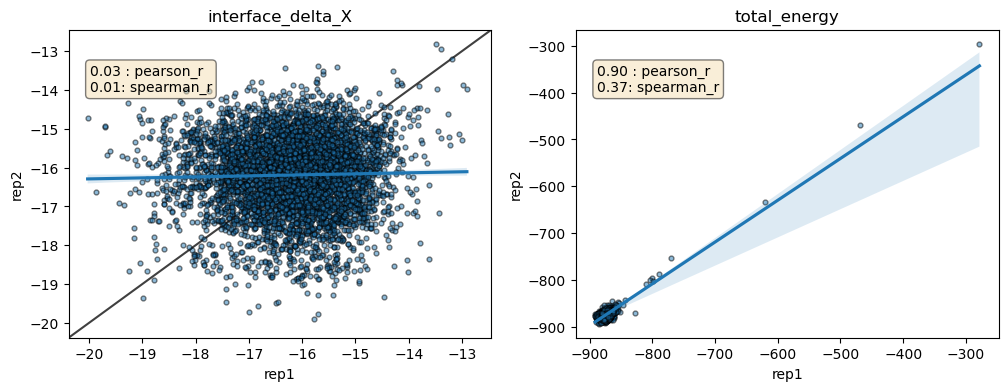

In [14]:
nrows=1
col_wrap=2
scatter_kws={'s':12, 'edgecolor':'k', 'alpha':0.5}

fig, axs = plt.subplots(nrows=nrows, ncols=col_wrap, figsize=(6*col_wrap, 4*nrows))

ax = axs[0]
sns.regplot(x=df.interface_delta_X_x, y=df.interface_delta_X_y, ax=ax,
                       scatter_kws=scatter_kws)
ax.set_xlabel("rep1")
ax.set_ylabel("rep2")
ax.set_title("interface_delta_X")
annotate_facet_with_correlations(x=df.interface_delta_X_x,  
                                 y=df.interface_delta_X_y,
                                             ax=ax)

# from https://stackoverflow.com/questions/25497402/adding-y-x-to-a-matplotlib-scatter-plot-if-i-havent-kept-track-of-all-the-data
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]

# now plot both limits against eachother
ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
#ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)

ax = axs[1]
sns.regplot(x=df.total_energy_x, y=df.total_energy_y, ax=ax,
                       scatter_kws=scatter_kws)
ax.set_xlabel("rep1")
ax.set_ylabel("rep2")
ax.set_title("total_energy")
annotate_facet_with_correlations(x=df.total_energy_x,  
                                 y=df.total_energy_y,
                                             ax=ax)




pass

In [15]:
# take rep1 and make a mutation map
mut_df = df[['variant', 'interface_delta_X_x']].copy()
mut_df["mut_aa"] = mut_df.variant.str.get(-1)
mut_df["mut_pos"] = mut_df.variant.str.slice(1, -1).astype(int)
mut_df

,variant,interface_delta_X_x,mut_aa,mut_pos
0,Y143R,-16.707,R,143
1,D158S,-15.947,S,158
2,Q236D,-17.706,D,236
3,Q82F,-16.263,F,82
4,Q177L,-17.367,L,177
...,...,...,...,...
5110,I263F,-15.758,F,263
5111,A37Y,-16.008,Y,37
5112,R214Y,-16.928,Y,214
5113,R255C,-17.246,C,255


<AxesSubplot: xlabel='interface_delta_X_x', ylabel='Count'>

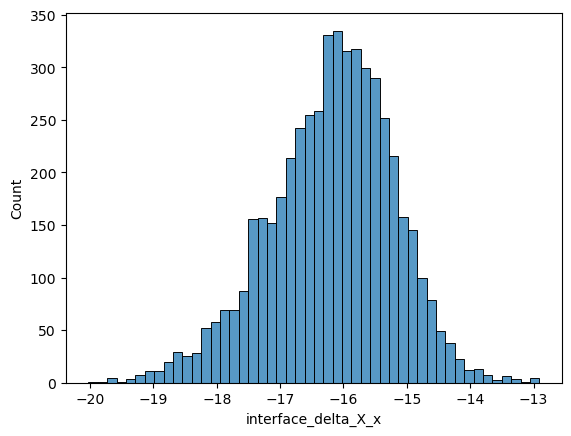

In [16]:
sns.histplot(mut_df.interface_delta_X_x)

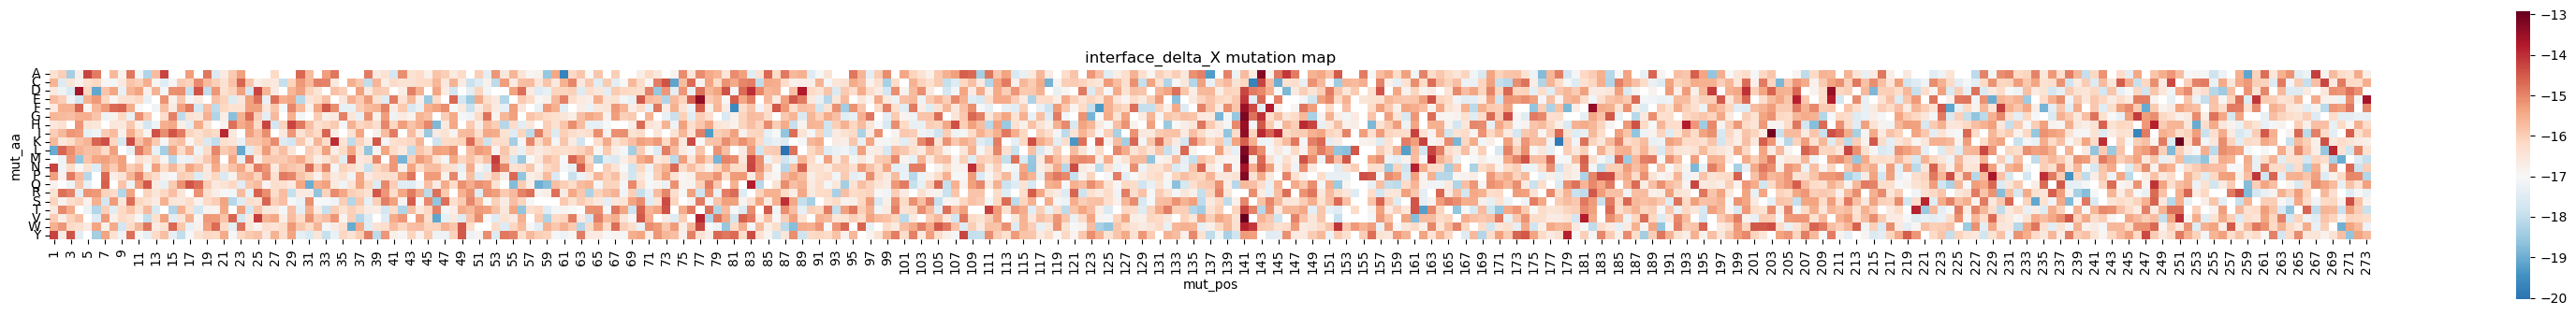

In [17]:
plt.figure(figsize=(40,4))
fig = sns.heatmap(mut_df.pivot(index="mut_aa", columns="mut_pos", values="interface_delta_X_x"), 
                  center = -17, cmap = 'RdBu_r', square = True)
plt.title("interface_delta_X mutation map")
plt.savefig("../output/rosetta_redo_with_wholerelax.png", dpi=300)
pass